[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reinhart-group/generative-copolymer-workshop/blob/main/day2/04_embedding.ipynb)

# Day 2, Morning: Dimensionality Reduction & the Structure Map

Today's topics:
* The curse of dimensionality: why 1280-D distances stop meaning anything
* PCA from scratch (numpy SVD) and what "variance explained" buys us
* The deployed N=64 structure map, and how we know to trust it
* A representation-validity caution: embedding axes can encode trivial factors
* Representation design, empirically: does channel-packing or merge strategy change what the CNN sees?
* (Optional) UMAP as a non-linear alternative

Day 1 gave every simulated structure a 1280-number fingerprint $x$.
Today we squeeze $x$ down to a handful of dimensions we can actually look at ($z$), and check that "close on the map" means "similar morphology."

We start with a big pile of numbers describing polymer structures.
We squeeze each structure down to a point on a 2-D map, then read that map to see which structures resemble which.
That map is what we mean by an **embedding**, or *latent space*.

It's also the actual method the Reinhart group uses in its own research (Statt, Kleeblatt & Reinhart 2021), where a two-stage UMAP pipeline recovered a continuous 2-D morphology map from raw structural features with almost no human input: no hand-picked order parameter, just neighbor-geometry features fed through UMAP.

Today's structure map is built the same way in spirit, with one twist.
On our data, plain linear PCA already captures the real morphology signal (we validate this below against real descriptors), so PCA, not UMAP, is the map we deploy for the rest of the course.
UMAP reappears at the end as an optional check on that choice.

## Where this comes from

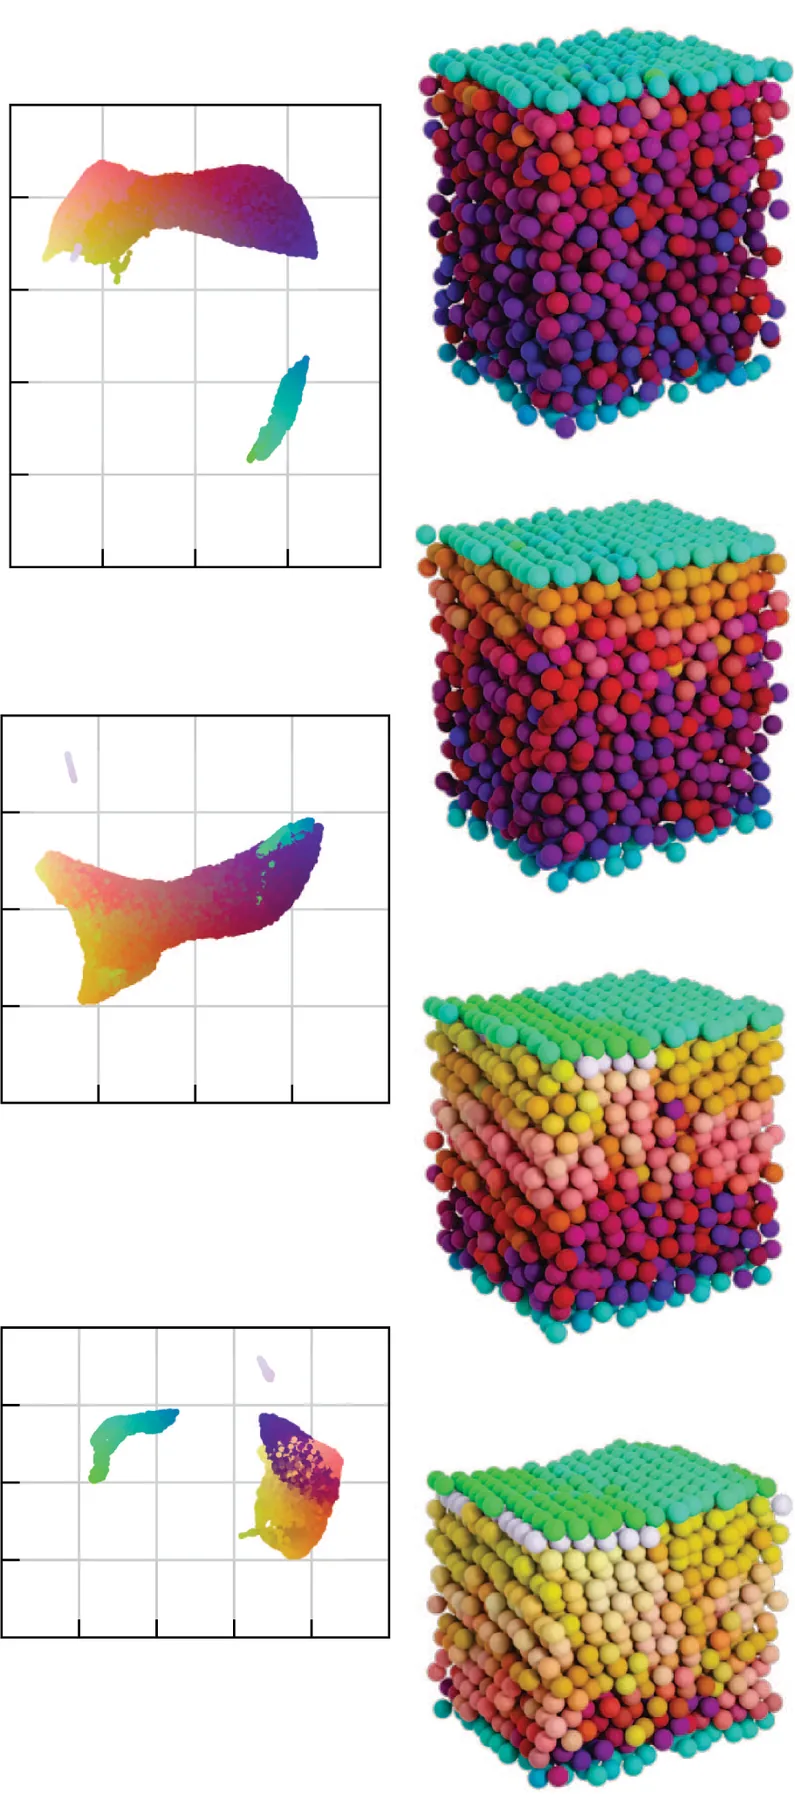

*Fig. 3. Reinhart, Comput. Mater. Sci. **196**, 110511 (2021). [doi.org/10.1016/j.commatsci.2021.110511](https://doi.org/10.1016/j.commatsci.2021.110511)*

The paper links low-dimensional coordinates to physical snapshots: color in latent space becomes color on the particles.
The coordinates matter because they organize structures, not because they make a tidy plot.

We make the same scientific move with a different pipeline.
The paper used local three-body features and UMAP.
The workshop uses pooled EfficientNet features and PCA on 64 sequences.

Sections 5 and 6 test whether our coordinates track real descriptors and visible morphology.
The appendix then asks whether UMAP improves the result.
That comparison, not resemblance alone, is the bridge back to the paper.

This notebook is an outline of the session: the topics above and the published work it builds on.
The complete notebook, with its code and exercises, will be posted before the workshop begins on August 7.